## Download the Dataset

In [ ]:
import kagglehub
path = kagglehub.dataset_download("uwrfkaggler/ravdess-emotional-speech-audio")
print("Path to dataset files:", path)

Using Colab cache for faster access to the 'ravdess-emotional-speech-audio' dataset.
Path to dataset files: /kaggle/input/ravdess-emotional-speech-audio


In [ ]:
PATH = path

In [ ]:
import os
for dirname, _, filenames in os.walk(PATH):
    for i , filename in enumerate(filenames):
        if (i == 10) : break
        print(os.path.join(dirname, filename))

/kaggle/input/ravdess-emotional-speech-audio/Actor_02/03-01-08-01-01-01-02.wav
/kaggle/input/ravdess-emotional-speech-audio/Actor_02/03-01-01-01-01-01-02.wav
/kaggle/input/ravdess-emotional-speech-audio/Actor_02/03-01-07-02-01-02-02.wav
/kaggle/input/ravdess-emotional-speech-audio/Actor_02/03-01-07-01-01-02-02.wav
/kaggle/input/ravdess-emotional-speech-audio/Actor_02/03-01-01-01-02-01-02.wav
/kaggle/input/ravdess-emotional-speech-audio/Actor_02/03-01-06-02-02-01-02.wav
/kaggle/input/ravdess-emotional-speech-audio/Actor_02/03-01-04-01-02-01-02.wav
/kaggle/input/ravdess-emotional-speech-audio/Actor_02/03-01-01-01-01-02-02.wav
/kaggle/input/ravdess-emotional-speech-audio/Actor_02/03-01-02-01-01-02-02.wav
/kaggle/input/ravdess-emotional-speech-audio/Actor_02/03-01-03-01-01-01-02.wav
/kaggle/input/ravdess-emotional-speech-audio/Actor_17/03-01-02-01-02-02-17.wav
/kaggle/input/ravdess-emotional-speech-audio/Actor_17/03-01-05-02-01-02-17.wav
/kaggle/input/ravdess-emotional-speech-audio/Actor_1

In [ ]:

ravdess_path = "/kaggle/input/ravdess-emotional-speech-audio/audio_speech_actors_01-24/"
crema_path = "/kaggle/input/cremad/AudioWAV/"
tess_path = "/kaggle/input/toronto-emotional-speech-set-tess/tess toronto emotional speech set data/TESS Toronto emotional speech set data/"
savee_path = "/kaggle/input/surrey-audiovisual-expressed-emotion-savee/ALL/"

## Importing the Library

In [ ]:
import tensorflow as tf
import pandas as pd
import numpy as np
import os
import sys
import librosa
import librosa.display
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import train_test_split
from IPython.display import Audio
import keras
from keras.callbacks import ReduceLROnPlateau
from keras.models import Sequential
from keras.layers import Dense, Conv1D, MaxPooling1D, Flatten, Dropout, BatchNormalization, Activation
from keras.utils import to_categorical
from keras.callbacks import ModelCheckpoint

In [ ]:
all_audio_path = []
for actor_dir_name in os.listdir(ravdess_path):
  actor_full_path = os.path.join(ravdess_path, actor_dir_name)
  if os.path.isdir(actor_full_path):
    for audio_file_name in os.listdir(actor_full_path):
      all_audio_path.append(os.path.join(actor_full_path, audio_file_name))

In [ ]:
len(all_audio_path)

1440

In [ ]:
all_audio_path[:5]

['/kaggle/input/ravdess-emotional-speech-audio/audio_speech_actors_01-24/Actor_02/03-01-08-01-01-01-02.wav',
 '/kaggle/input/ravdess-emotional-speech-audio/audio_speech_actors_01-24/Actor_02/03-01-01-01-01-01-02.wav',
 '/kaggle/input/ravdess-emotional-speech-audio/audio_speech_actors_01-24/Actor_02/03-01-07-02-01-02-02.wav',
 '/kaggle/input/ravdess-emotional-speech-audio/audio_speech_actors_01-24/Actor_02/03-01-07-01-01-02-02.wav',
 '/kaggle/input/ravdess-emotional-speech-audio/audio_speech_actors_01-24/Actor_02/03-01-01-01-02-01-02.wav']

In [ ]:
import os

file_emotion, file_path = [], []
for audio in all_audio_path:
    basename = os.path.basename(audio)
    # Get filename without extension
    filename_without_ext = os.path.splitext(basename)[0]
    part = filename_without_ext.split('-')
    # third part in each file represents the emotion associated to that file.
    file_emotion.append(int(part[2]))
    file_path.append(audio)
emotion_df = pd.DataFrame(file_emotion, columns=['Emotions'])

# dataframe for path of files.
path_df = pd.DataFrame(file_path, columns=['Path'])
Ravdess_df = pd.concat([emotion_df, path_df], axis=1)

# changing integers to actual emotions.
Ravdess_df.Emotions.replace({1:'neutral',
                             2:'calm',
                             3:'happy',
                             4:'sad',
                             5:'angry',
                             6:'fear',
                             7:'disgust',
                             8:'surprise'
                             },
                             inplace=True)
Ravdess_df

/tmp/ipykernel_6820/2794084462.py:19: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  Ravdess_df.Emotions.replace({1:'neutral',


,Emotions,Path
0,surprise,/kaggle/input/ravdess-emotional-speech-audio/a...
1,neutral,/kaggle/input/ravdess-emotional-speech-audio/a...
2,disgust,/kaggle/input/ravdess-emotional-speech-audio/a...
3,disgust,/kaggle/input/ravdess-emotional-speech-audio/a...
4,neutral,/kaggle/input/ravdess-emotional-speech-audio/a...
...,...,...
1435,fear,/kaggle/input/ravdess-emotional-speech-audio/a...
1436,angry,/kaggle/input/ravdess-emotional-speech-audio/a...
1437,sad,/kaggle/input/ravdess-emotional-speech-audio/a...
1438,disgust,/kaggle/input/ravdess-emotional-speech-audio/a...


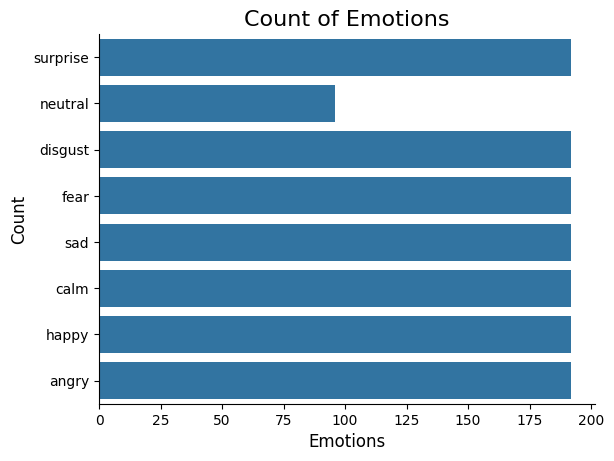

In [ ]:

plt.title('Count of Emotions', size=16)
sns.countplot(Ravdess_df.Emotions)
plt.ylabel('Count', size=12)
plt.xlabel('Emotions', size=12)
sns.despine(top=True, right=True, left=False, bottom=False)
plt.show()

In [ ]:
def create_waveplot(data, sr, e):
    plt.figure(figsize=(10, 3))
    plt.title('Waveplot for audio with {} emotion'.format(e), size=15)
    librosa.display.waveshow(data, sr=sr)
    plt.show()

In [ ]:
def create_spectrogram(data, sr, e):
    # stft function converts the data into short term fourier transform
    X = librosa.stft(data)
    Xdb = librosa.amplitude_to_db(abs(X))
    plt.figure(figsize=(12, 3))
    plt.title('Spectrogram for audio with {} emotion'.format(e), size=15)
    librosa.display.specshow(Xdb, sr=sr, x_axis='time', y_axis='hz')
    #librosa.display.specshow(Xdb, sr=sr, x_axis='time', y_axis='log')
    plt.colorbar()

/kaggle/input/ravdess-emotional-speech-audio/audio_speech_actors_01-24/Actor_02/03-01-06-02-01-02-02.wav


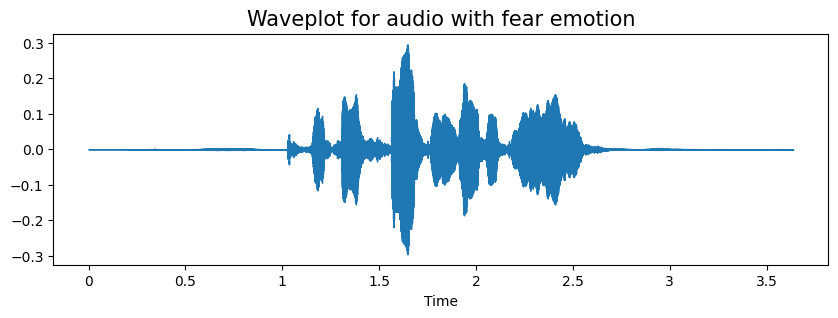

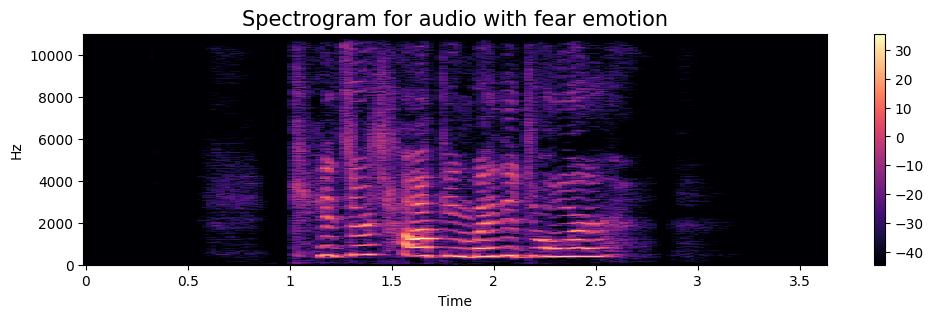

In [ ]:
emotion='fear'
path = np.array(Ravdess_df.Path[Ravdess_df.Emotions==emotion])[1]
print(path)
data, sampling_rate = librosa.load(path)
create_waveplot(data, sampling_rate, emotion)
create_spectrogram(data, sampling_rate, emotion)
Audio(path)

/kaggle/input/ravdess-emotional-speech-audio/audio_speech_actors_01-24/Actor_02/03-01-05-02-01-01-02.wav


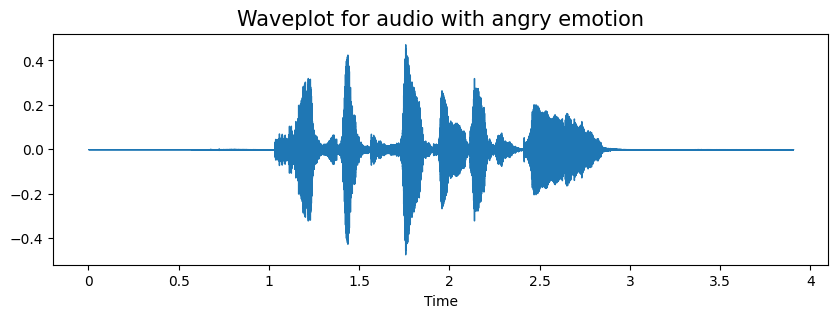

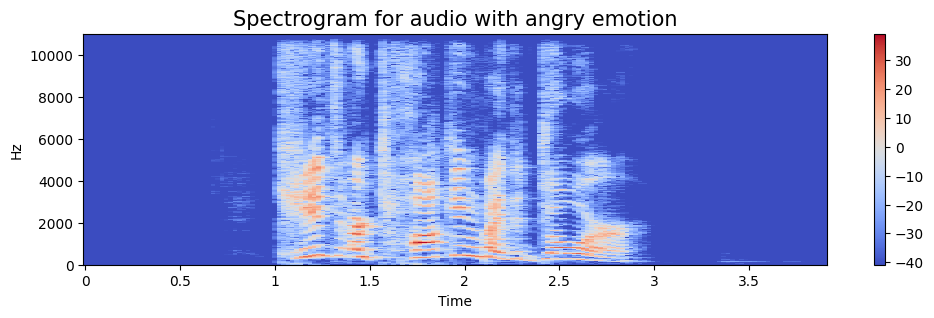

In [ ]:

emotion='angry'
path = np.array(Ravdess_df.Path[Ravdess_df.Emotions==emotion])[1]
print(path)
data, sampling_rate = librosa.load(path)
create_waveplot(data, sampling_rate, emotion)
create_spectrogram(data, sampling_rate, emotion)
Audio(path)

/kaggle/input/ravdess-emotional-speech-audio/audio_speech_actors_01-24/Actor_02/03-01-04-02-02-02-02.wav


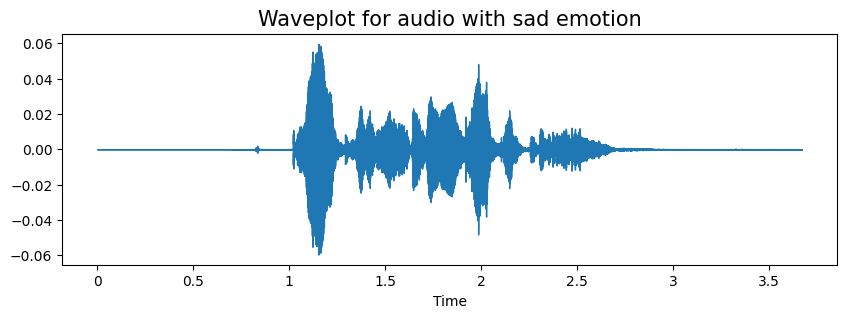

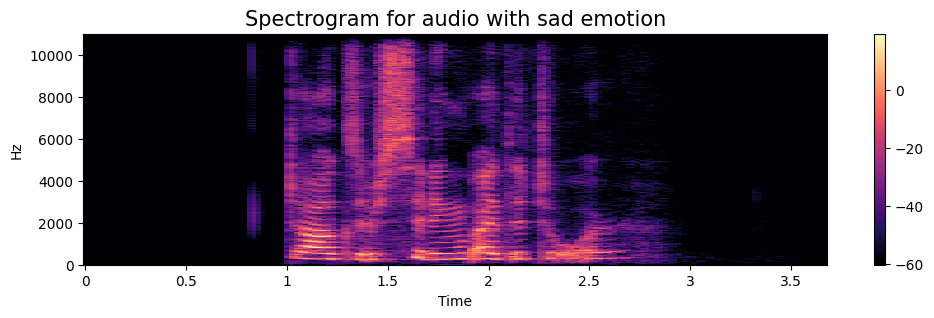

In [ ]:

emotion='sad'
path = np.array(Ravdess_df.Path[Ravdess_df.Emotions==emotion])[1]
print(path)
data, sampling_rate = librosa.load(path)
create_waveplot(data, sampling_rate, emotion)
create_spectrogram(data, sampling_rate, emotion)
Audio(path)

/kaggle/input/ravdess-emotional-speech-audio/audio_speech_actors_01-24/Actor_02/03-01-03-01-01-02-02.wav


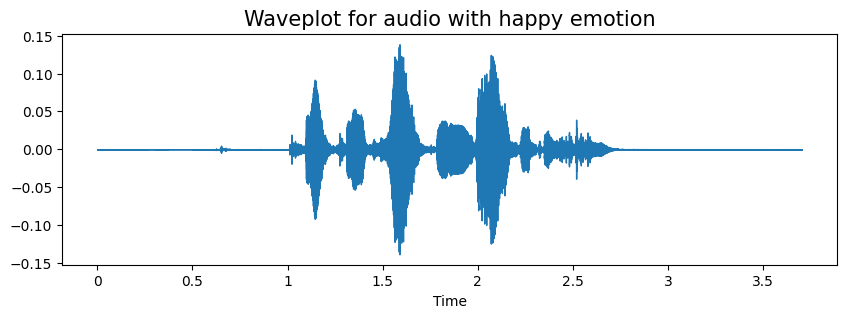

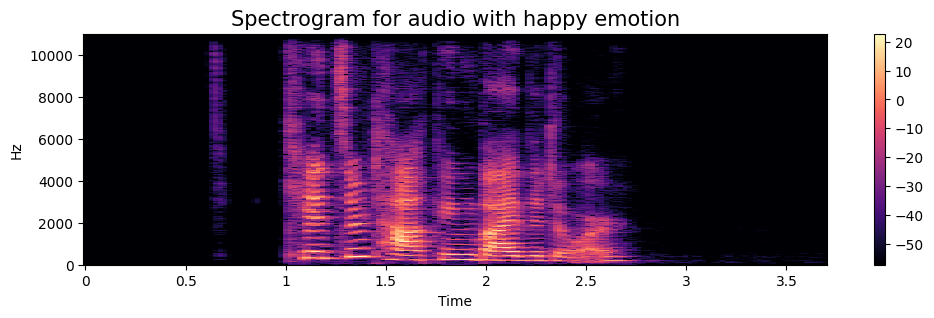

In [ ]:

emotion='happy'
path = np.array(Ravdess_df.Path[Ravdess_df.Emotions==emotion])[1]
print(path)
data, sampling_rate = librosa.load(path)
create_waveplot(data, sampling_rate, emotion)
create_spectrogram(data, sampling_rate, emotion)
Audio(path)

In [ ]:
def noise(data):
    noise_amp = 0.035*np.random.uniform()*np.amax(data)
    data = data + noise_amp*np.random.normal(size=data.shape[0])
    return data

def stretch(data, rate=0.8):
    return librosa.effects.time_stretch(data, rate=0.8)

def shift(data):
    shift_range = int(np.random.uniform(low=-5, high = 5)*1000)
    return np.roll(data, shift_range)

def pitch(data, sampling_rate=0.3, pitch_factor=0.7):
    return librosa.effects.pitch_shift(data, sr=0.5, n_steps=4)

# taking any example and checking for techniques.
path = np.array(Ravdess_df.Path)[1]
data, sample_rate = librosa.load(path)

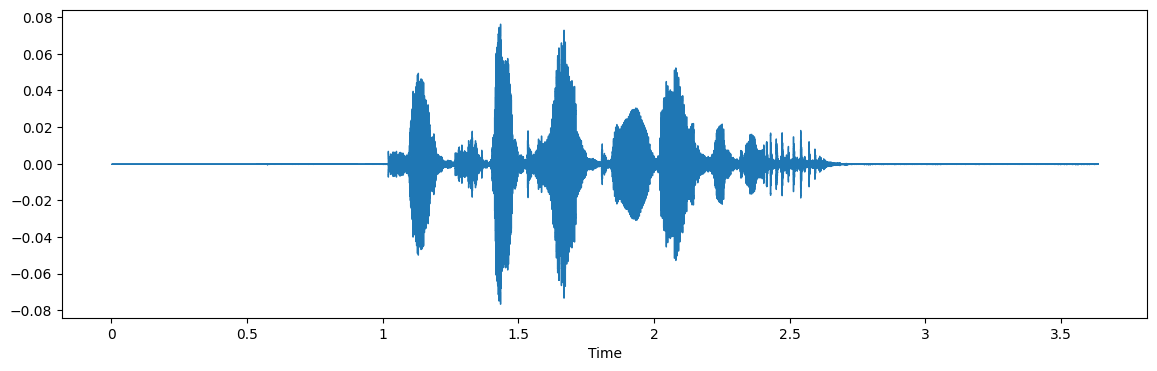

In [ ]:

plt.figure(figsize=(14,4))
librosa.display.waveshow(y=data, sr=sample_rate)
Audio(path)

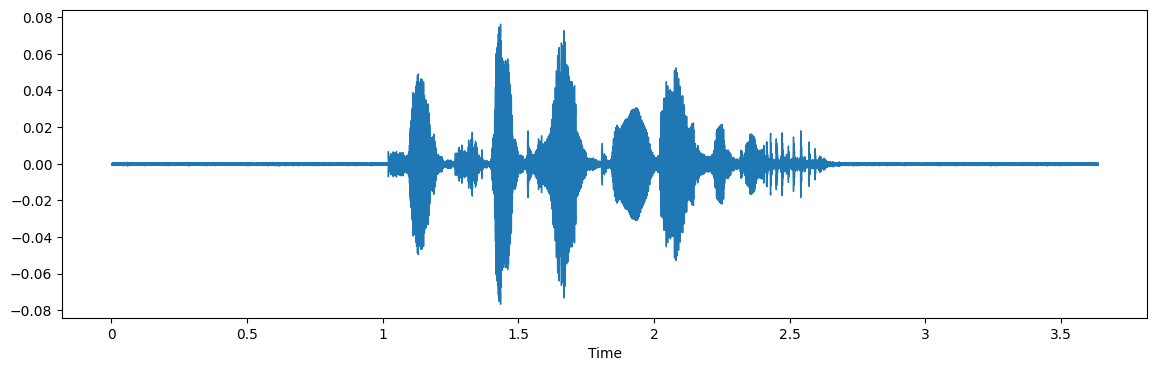

In [ ]:
x = noise(data)
plt.figure(figsize=(14,4))
librosa.display.waveshow(y=x, sr=sample_rate)
Audio(x, rate=sample_rate)

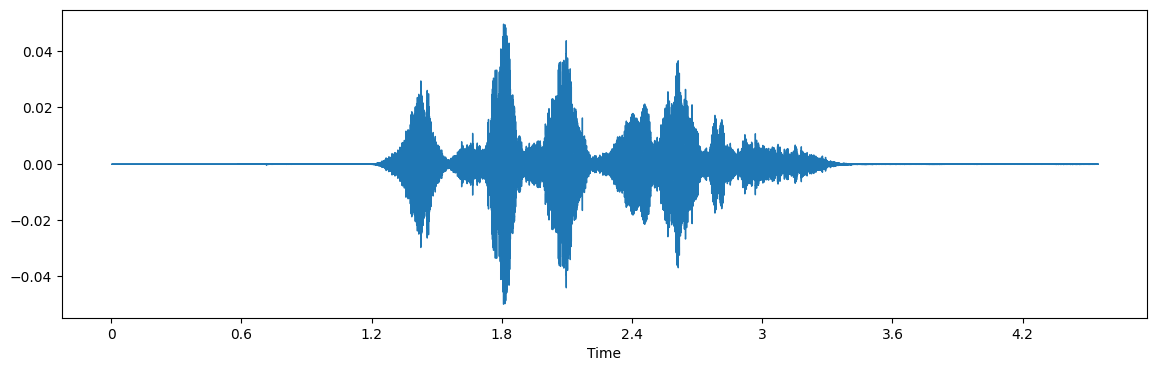

In [ ]:
x = stretch(data)
plt.figure(figsize=(14,4))
librosa.display.waveshow(y=x, sr=sample_rate)
Audio(x, rate=sample_rate)

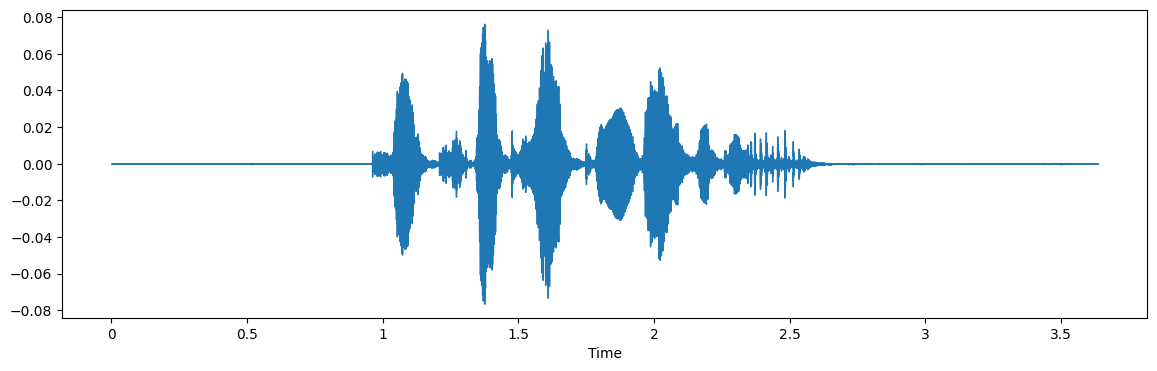

In [ ]:

x = shift(data)
plt.figure(figsize=(14,4))
librosa.display.waveshow(y=x, sr=sample_rate)
Audio(x, rate=sample_rate)

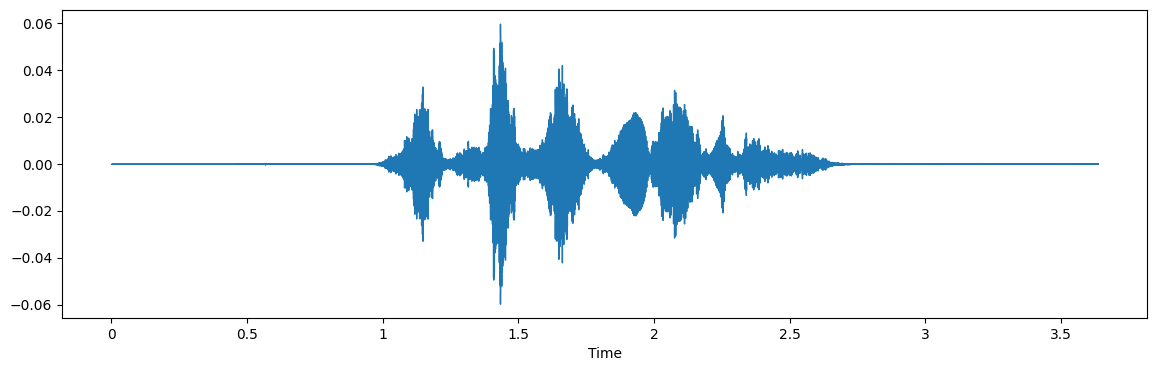

In [ ]:

x = pitch(data, sample_rate)
plt.figure(figsize=(14,4))
librosa.display.waveshow(y=x, sr=sample_rate)
Audio(x, rate=sample_rate)

In [ ]:
def extract_features(data):
    # ZCR
    result = np.array([])
    zcr = np.mean(librosa.feature.zero_crossing_rate(y=data).T, axis=0)
    result=np.hstack((result, zcr)) # stacking horizontally

    # Chroma_stft
    stft = np.abs(librosa.stft(data))
    chroma_stft = np.mean(librosa.feature.chroma_stft(S=stft, sr=sample_rate).T, axis=0)
    result = np.hstack((result, chroma_stft)) # stacking horizontally

    # MFCC
    mfcc = np.mean(librosa.feature.mfcc(y=data, sr=sample_rate).T, axis=0)
    result = np.hstack((result, mfcc)) # stacking horizontally

    # Root Mean Square Value
    rms = np.mean(librosa.feature.rms(y=data).T, axis=0)
    result = np.hstack((result, rms)) # stacking horizontally

    # MelSpectogram
    mel = np.mean(librosa.feature.melspectrogram(y=data, sr=sample_rate).T, axis=0)
    result = np.hstack((result, mel)) # stacking horizontally

    return result

In [ ]:

def get_features(path):
    # duration and offset are used to take care of the no audio in start and the ending of each audio files as seen above.
    data, sample_rate = librosa.load(path, duration=2.5, offset=0.6)

    # without augmentation
    res1 = extract_features(data)
    result = np.array(res1)

    # data with noise
    noise_data = noise(data)
    res2 = extract_features(noise_data)
    result = np.vstack((result, res2)) # stacking vertically

    # data with stretching and pitching
    new_data = stretch(data)
    data_stretch_pitch = pitch(new_data, sample_rate)
    res3 = extract_features(data_stretch_pitch)
    result = np.vstack((result, res3)) # stacking vertically

    return result

In [ ]:
X, Y = [], []
for path, emotion in zip(Ravdess_df.Path, Ravdess_df.Emotions):
    feature = get_features(path)
    for ele in feature:
        X.append(ele)
        # appending emotion 3 times as we have made 3 augmentation techniques on each audio file.
        Y.append(emotion)

In [ ]:
len(X), len(Y), Ravdess_df.Path.shape

(4320, 4320, (1440,))

In [ ]:

Features = pd.DataFrame(X)
Features['labels'] = Y
Features.to_csv('/kaggle/working/features.csv', index=False)
Features

,0,1,2,3,4,5,6,7,8,9,...,153,154,155,156,157,158,159,160,161,labels
0,0.237382,0.682273,0.670519,0.614793,0.579039,0.566803,0.637206,0.667451,0.663883,0.669903,...,0.000234,0.000235,0.000138,0.000128,0.000299,0.000360,0.000275,0.000173,2.896729e-05,surprise
1,0.335965,0.726269,0.740611,0.738052,0.716070,0.729141,0.747425,0.705362,0.684168,0.694512,...,0.001468,0.001435,0.001414,0.001479,0.001655,0.001654,0.001523,0.001391,1.205116e-03,surprise
2,0.206427,0.674998,0.688611,0.712488,0.710041,0.643866,0.597580,0.552462,0.500958,0.517250,...,0.000058,0.000037,0.000046,0.000030,0.000048,0.000047,0.000057,0.000027,2.675169e-06,surprise
3,0.256113,0.621621,0.580278,0.598515,0.628296,0.598015,0.597272,0.650352,0.698635,0.681863,...,0.000018,0.000016,0.000013,0.000012,0.000007,0.000008,0.000008,0.000005,5.802854e-07,neutral
4,0.348637,0.723666,0.724608,0.766624,0.789336,0.752782,0.677761,0.706760,0.742518,0.739398,...,0.000463,0.000467,0.000426,0.000446,0.000438,0.000428,0.000461,0.000464,4.280896e-04,neutral
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4315,0.201380,0.541245,0.601227,0.638375,0.701177,0.697878,0.636715,0.612698,0.617854,0.693505,...,0.001972,0.001892,0.002290,0.003130,0.003152,0.002678,0.002444,0.001225,1.131523e-04,disgust
4316,0.219079,0.713557,0.609418,0.546588,0.548750,0.458908,0.509039,0.537314,0.622186,0.651991,...,0.000347,0.000364,0.000637,0.000701,0.000622,0.000633,0.000518,0.000233,1.205778e-05,disgust
4317,0.148537,0.656566,0.652982,0.634403,0.652929,0.608521,0.557056,0.550457,0.628574,0.665743,...,0.014213,0.015852,0.012141,0.011468,0.008031,0.010061,0.015541,0.008099,5.346318e-04,angry
4318,0.246388,0.695141,0.696637,0.715365,0.727545,0.697740,0.599320,0.576394,0.658470,0.676385,...,0.018614,0.019393,0.015996,0.015504,0.012113,0.014098,0.019902,0.011889,4.634541e-03,angry


In [ ]:
X = Features.iloc[: ,:-1].values
Y = Features['labels'].values
encoder = OneHotEncoder()
Y = encoder.fit_transform(np.array(Y).reshape(-1,1)).toarray()

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(X, Y, random_state=0, shuffle=True)

In [ ]:
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [ ]:
x_train = np.expand_dims(x_train, axis=2)
x_test = np.expand_dims(x_test, axis=2)

## PyTorch Model Implementation



In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

# Check for GPU availability
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


In [ ]:
# Convert numpy arrays to PyTorch tensors
x_train_tensor = torch.tensor(x_train, dtype=torch.float32).permute(0, 2, 1).to(device) # (samples, 1, features)
x_test_tensor = torch.tensor(x_test, dtype=torch.float32).permute(0, 2, 1).to(device)   # (samples, 1, features)

# For CrossEntropyLoss, target should be class indices, not one-hot encoded
# So, we convert y_train and y_test back to class indices from one-hot
y_train_labels = torch.argmax(torch.tensor(y_train, dtype=torch.float32), dim=1).to(device)
y_test_labels = torch.argmax(torch.tensor(y_test, dtype=torch.float32), dim=1).to(device)

# Create TensorDatasets
train_dataset = TensorDataset(x_train_tensor, y_train_labels)
test_dataset = TensorDataset(x_test_tensor, y_test_labels)

# Create DataLoaders
batch_size = 64 # Use a common batch size
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"x_train_tensor shape: {x_train_tensor.shape}")
print(f"y_train_labels shape: {y_train_labels.shape}")

x_train_tensor shape: torch.Size([3240, 1, 162])
y_train_labels shape: torch.Size([3240])


In [ ]:
class CNNModel(nn.Module):
    def __init__(self, input_features, num_classes):
        super(CNNModel, self).__init__()
        self.conv1 = nn.Sequential(
            nn.Conv1d(in_channels=1, out_channels=256, kernel_size=10, stride=1, padding='same'),
            nn.ReLU()
        )
        self.conv2 = nn.Sequential(
            nn.Conv1d(in_channels=256, out_channels=128, kernel_size=5, stride=1, padding='same'),
            nn.ReLU()
        )
        self.dropout1 = nn.Dropout(0.2)
        # Changed padding='same' to padding=2 for nn.MaxPool1d
        self.maxpool1 = nn.MaxPool1d(kernel_size=5, stride=2, padding=2)

        self.conv3 = nn.Sequential(
            nn.Conv1d(in_channels=128, out_channels=128, kernel_size=5, stride=1, padding='same'),
            nn.ReLU()
        )
        self.conv4 = nn.Sequential(
            nn.Conv1d(in_channels=128, out_channels=128, kernel_size=5, stride=1, padding='same'),
            nn.ReLU()
        )
        self.conv5 = nn.Sequential(
            nn.Conv1d(in_channels=128, out_channels=128, kernel_size=5, stride=1, padding='same'),
            nn.ReLU()
        )
        self.dropout2 = nn.Dropout(0.3)
        self.conv6 = nn.Sequential(
            nn.Conv1d(in_channels=128, out_channels=64, kernel_size=5, stride=1, padding='same'),
            nn.ReLU()
        )

        # Calculate flattened size dynamically
        # Need to pass a dummy tensor through the conv layers to determine the size
        # Let's assume input_features is the length dimension, in_channels is 1
        dummy_input = torch.randn(1, 1, input_features)
        # Pass through conv layers to calculate output size
        x = self.conv1(dummy_input)
        x = self.conv2(x)
        x = self.maxpool1(x)
        x = self.conv3(x)
        x = self.conv4(x)
        x = self.conv5(x)
        x = self.conv6(x)
        flattened_size = x.numel() # Get total number of elements

        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(flattened_size, 32)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(32, num_classes)

    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.dropout1(x)
        x = self.maxpool1(x)

        x = self.conv3(x)
        x = self.conv4(x)
        x = self.conv5(x)
        x = self.dropout2(x)
        x = self.conv6(x)

        x = self.flatten(x)
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x

In [ ]:
# Initialize the model, loss function, and optimizer
input_features = x_train.shape[1] # This is the length dimension for Conv1D
num_classes = y_train.shape[1] # Number of emotion classes

model = CNNModel(input_features, num_classes).to(device)

# For multi-class classification with class indices as targets, CrossEntropyLoss is appropriate.
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)

print(model)

CNNModel(
  (conv1): Sequential(
    (0): Conv1d(1, 256, kernel_size=(10,), stride=(1,), padding=same)
    (1): ReLU()
  )
  (conv2): Sequential(
    (0): Conv1d(256, 128, kernel_size=(5,), stride=(1,), padding=same)
    (1): ReLU()
  )
  (dropout1): Dropout(p=0.2, inplace=False)
  (maxpool1): MaxPool1d(kernel_size=5, stride=2, padding=2, dilation=1, ceil_mode=False)
  (conv3): Sequential(
    (0): Conv1d(128, 128, kernel_size=(5,), stride=(1,), padding=same)
    (1): ReLU()
  )
  (conv4): Sequential(
    (0): Conv1d(128, 128, kernel_size=(5,), stride=(1,), padding=same)
    (1): ReLU()
  )
  (conv5): Sequential(
    (0): Conv1d(128, 128, kernel_size=(5,), stride=(1,), padding=same)
    (1): ReLU()
  )
  (dropout2): Dropout(p=0.3, inplace=False)
  (conv6): Sequential(
    (0): Conv1d(128, 64, kernel_size=(5,), stride=(1,), padding=same)
    (1): ReLU()
  )
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=5184, out_features=32, bias=True)
  (relu): ReLU()
  (fc2

In [ ]:
# Training Loop
epochs = 50
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

for epoch in range(epochs):
    model.train() # Set model to training mode
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad() # Zero the parameter gradients

        outputs = model(inputs) # Forward pass
        loss = criterion(outputs, labels) # Calculate loss
        loss.backward() # Backward pass
        optimizer.step() # Optimize

        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs.data, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    epoch_train_loss = running_loss / len(train_loader.dataset)
    epoch_train_acc = correct_train / total_train

    # Validation step
    model.eval() # Set model to evaluation mode
    val_loss = 0.0
    correct_val = 0
    total_val = 0
    with torch.no_grad(): # Disable gradient calculation for validation
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()

    epoch_val_loss = val_loss / len(test_loader.dataset)
    epoch_val_acc = correct_val / total_val

    history['train_loss'].append(epoch_train_loss)
    history['train_acc'].append(epoch_train_acc)
    history['val_loss'].append(epoch_val_loss)
    history['val_acc'].append(epoch_val_acc)

    print(f'Epoch {epoch+1}/{epochs}, '
          f'Train Loss: {epoch_train_loss:.4f}, Train Acc: {epoch_train_acc:.4f}, '
          f'Val Loss: {epoch_val_loss:.4f}, Val Acc: {epoch_val_acc:.4f}')

Epoch 1/50, Train Loss: 1.9998, Train Acc: 0.1725, Val Loss: 1.9148, Val Acc: 0.2139
Epoch 2/50, Train Loss: 1.8699, Train Acc: 0.2676, Val Loss: 1.8148, Val Acc: 0.3343
Epoch 3/50, Train Loss: 1.7800, Train Acc: 0.3148, Val Loss: 1.7537, Val Acc: 0.3324
Epoch 4/50, Train Loss: 1.6880, Train Acc: 0.3630, Val Loss: 1.6586, Val Acc: 0.3861
Epoch 5/50, Train Loss: 1.6149, Train Acc: 0.3904, Val Loss: 1.6218, Val Acc: 0.3917
Epoch 6/50, Train Loss: 1.5682, Train Acc: 0.4000, Val Loss: 1.5954, Val Acc: 0.3769
Epoch 7/50, Train Loss: 1.5442, Train Acc: 0.4204, Val Loss: 1.5701, Val Acc: 0.4046
Epoch 8/50, Train Loss: 1.5160, Train Acc: 0.4253, Val Loss: 1.6019, Val Acc: 0.4056
Epoch 9/50, Train Loss: 1.4893, Train Acc: 0.4448, Val Loss: 1.5388, Val Acc: 0.4259
Epoch 10/50, Train Loss: 1.4565, Train Acc: 0.4512, Val Loss: 1.5098, Val Acc: 0.4333
Epoch 11/50, Train Loss: 1.4036, Train Acc: 0.4728, Val Loss: 1.4842, Val Acc: 0.4380
Epoch 12/50, Train Loss: 1.3788, Train Acc: 0.4895, Val Loss: 1

In [ ]:
# Plotting training and validation history
epochs_range = range(epochs)

plt.figure(figsize=(20, 6))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, history['train_loss'], label='Training Loss')
plt.plot(epochs_range, history['val_loss'], label='Validation Loss')
plt.title('Training & Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_range, history['train_acc'], label='Training Accuracy')
plt.plot(epochs_range, history['val_acc'], label='Validation Accuracy')
plt.title('Training & Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

In [ ]:
# Evaluate the model on the test data and get predictions
model.eval()
all_predictions = []
all_labels = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, predicted = torch.max(outputs.data, 1)
        all_predictions.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Convert predictions and actual labels to original emotion names
y_pred_indices = np.array(all_predictions)
y_true_indices = np.array(all_labels)

# Use the encoder categories to map indices back to emotion names
# The encoder.categories_ is a list of arrays, like [array(['angry', 'calm', ...])]
# So, we need to access the first element of that list
emotion_labels = encoder.categories_[0]

y_pred_emotion = emotion_labels[y_pred_indices]
y_true_emotion = emotion_labels[y_true_indices]

# Print accuracy
accuracy = (y_pred_indices == y_true_indices).sum() / len(y_true_indices)
print(f"Accuracy of our model on test data: {accuracy * 100:.2f}%")

In [97]:

accuracy = (y_pred_indices == y_true_indices).sum() / len(y_true_indices)
print(f"Accuracy of our model on test data: {accuracy*100 :.2f}%")

Accuracy of our model on test data: 68.87%


In [ ]:
# Display a DataFrame of Predicted vs Actual Labels
df_results = pd.DataFrame(columns=['Predicted Labels', 'Actual Labels'])
df_results['Predicted Labels'] = y_pred_emotion
df_results['Actual Labels'] = y_true_emotion
display(df_results.head(10))

,Predicted Labels,Actual Labels
0,fear,fear
1,neutral,neutral
2,sad,sad
3,disgust,neutral
4,fear,fear
5,fear,angry
6,fear,fear
7,sad,fear
8,disgust,disgust
9,calm,calm


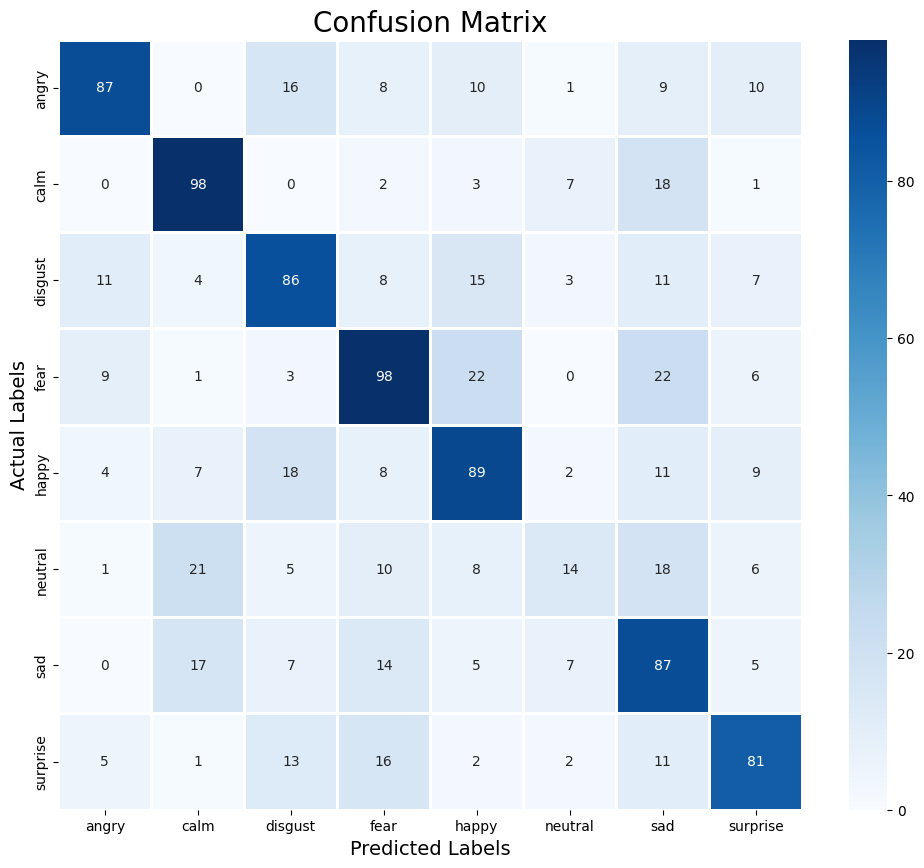

In [ ]:
# Confusion Matrix
cm = confusion_matrix(y_true_emotion, y_pred_emotion, labels=emotion_labels)
plt.figure(figsize = (12, 10))
sns.heatmap(cm, linecolor='white', cmap='Blues', linewidth=1, annot=True, fmt='', xticklabels=emotion_labels, yticklabels=emotion_labels)
plt.title('Confusion Matrix', size=20)
plt.xlabel('Predicted Labels', size=14)
plt.ylabel('Actual Labels', size=14)
plt.show()

In [ ]:
# Classification Report
print(classification_report(y_true_emotion, y_pred_emotion, target_names=emotion_labels))

              precision    recall  f1-score   support

       angry       0.74      0.62      0.67       141
        calm       0.66      0.76      0.71       129
     disgust       0.58      0.59      0.59       145
        fear       0.60      0.61      0.60       161
       happy       0.58      0.60      0.59       148
     neutral       0.39      0.17      0.24        83
         sad       0.47      0.61      0.53       142
    surprise       0.65      0.62      0.63       131

    accuracy                           0.59      1080
   macro avg       0.58      0.57      0.57      1080
weighted avg       0.59      0.59      0.59      1080



In [ ]:
path ="/kaggle/working/model.pth"

torch.save(model.state_dict(), path)

print("saved successfully")

saved successfully
